#  Netflix Content Strategy Analysis

**Dataset:** 8,807 Netflix titles (Movies + TV Shows)  
**Period:** 2008 — 2021  
**Tools:** Python, pandas, matplotlib, seaborn  

---

## Objective
Analyse Netflix's content library to identify strategic shifts, content acquisition patterns, geographic expansion trends, and seasonal addition behaviour — translating raw streaming data into content strategy insights.

## Business Questions
1. Is Netflix shifting strategy from Movies to TV Shows over time?
2. Which countries supply the most Netflix content — and what type?
3. What genres dominate the Netflix library?
4. How quickly does Netflix acquire content after release?
5. Which months does Netflix add the most content?
6. What is the rating distribution across content types?
7. Who are the most prolific directors on Netflix?

---
## 1. Setup & Imports

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from collections import Counter

# Plot styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

# Netflix brand colors
NETFLIX_RED  = '#E50914'
NETFLIX_BLUE = '#00A8E1'
NETFLIX_DARK = '#221F1F'

print('Libraries loaded successfully')

Libraries loaded successfully


---
## 2. Load Data

In [4]:
df = pd.read_csv(r"C:\Users\hp\Desktop\project analyst\netflix\netflix_titles.csv")
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


---
## 3. Data Exploration

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [7]:
print('=== NULL VALUES ===')
print(df.isnull().sum())
print(f'\n=== DUPLICATE ROWS ===')
print(f'Duplicates: {df[df.duplicated()].shape[0]}')

=== NULL VALUES ===
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

=== DUPLICATE ROWS ===
Duplicates: 0


---
## 4. Data Cleaning

In [8]:
# ── 4.1 Fill missing categorical values ──────────────────────────────────────
df['director'] = df['director'].fillna('Unknown')
df['cast']     = df['cast'].fillna('Unknown')
df['country']  = df['country'].fillna('Unknown')
df['rating']   = df['rating'].fillna('Not Rated')
df['duration'] = df['duration'].fillna('Unknown')

# ── 4.2 Fix data types ───────────────────────────────────────────────────────
df['date_added'] = pd.to_datetime(
    df['date_added'].str.strip(), errors='coerce', format='mixed'
)

# ── 4.3 Extract date features ────────────────────────────────────────────────
df['year_added']  = df['date_added'].dt.year.astype('Int64')
df['month_added'] = df['date_added'].dt.month.astype('Int64')

# ── 4.4 Drop rows where date_added is null ───────────────────────────────────
df.dropna(subset=['date_added'], inplace=True)

# ── 4.5 Engineer content age feature ─────────────────────────────────────────
df['content_age_when_added'] = df['year_added'] - df['release_year']

print('Data cleaning complete')
print(f'Final shape: {df.shape}')
print(f'\nNull values remaining:')
print(df.isnull().sum())

Data cleaning complete
Final shape: (8797, 15)

Null values remaining:
show_id                   0
type                      0
title                     0
director                  0
cast                      0
country                   0
date_added                0
release_year              0
rating                    0
duration                  0
listed_in                 0
description               0
year_added                0
month_added               0
content_age_when_added    0
dtype: int64


---
## 5. Exploratory Data Analysis

### BQ1: What is the overall split between Movies and TV Shows?

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

Movie share: 69.7%
TV Show share: 30.3%


C:\Users\hp\AppData\Local\Temp\ipykernel_28348\3012621285.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


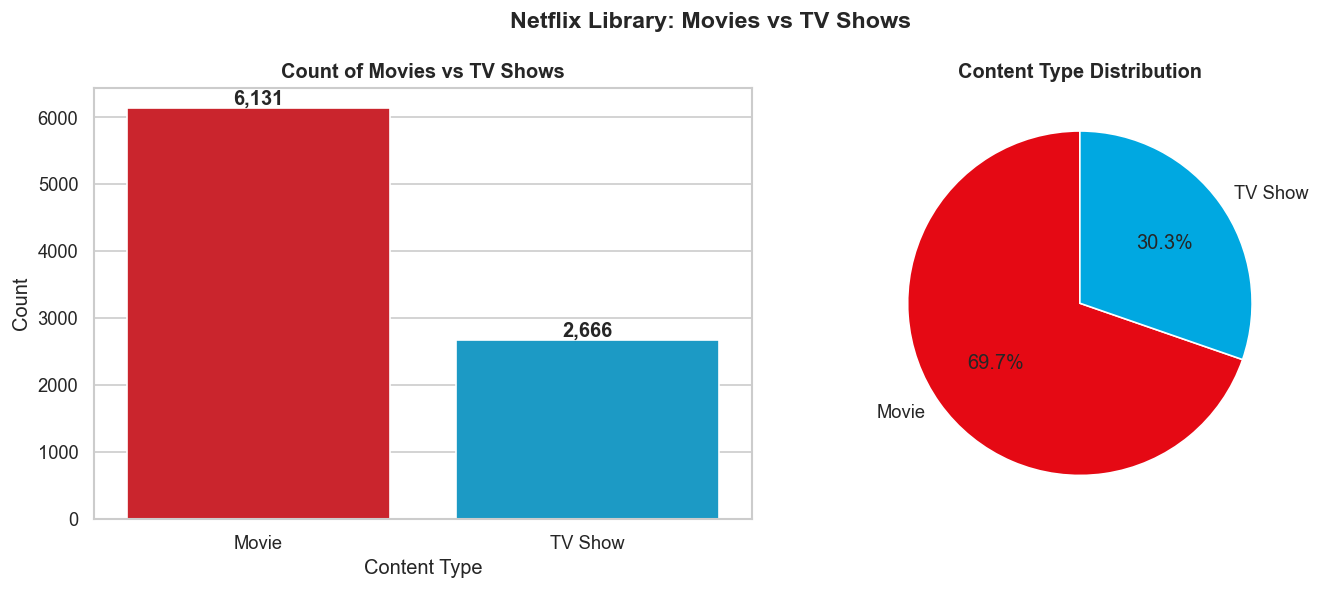

In [9]:
type_counts = df['type'].value_counts()
print(type_counts)
print(f'\nMovie share: {type_counts["Movie"]/len(df)*100:.1f}%')
print(f'TV Show share: {type_counts["TV Show"]/len(df)*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(
    x='type', data=df,
    palette={'Movie': NETFLIX_RED, 'TV Show': NETFLIX_BLUE},
    ax=axes[0]
)
axes[0].set_title('Count of Movies vs TV Shows', fontweight='bold')
axes[0].set_xlabel('Content Type')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=[NETFLIX_RED, NETFLIX_BLUE],
    startangle=90
)
axes[1].set_title('Content Type Distribution', fontweight='bold')

plt.suptitle('Netflix Library: Movies vs TV Shows', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Finding:** Movies dominate the Netflix library at ~69% of all content. However this ratio is changing over time — see BQ2 for the trend analysis.

---
### BQ2: Is Netflix shifting strategy from Movies to TV Shows over time?

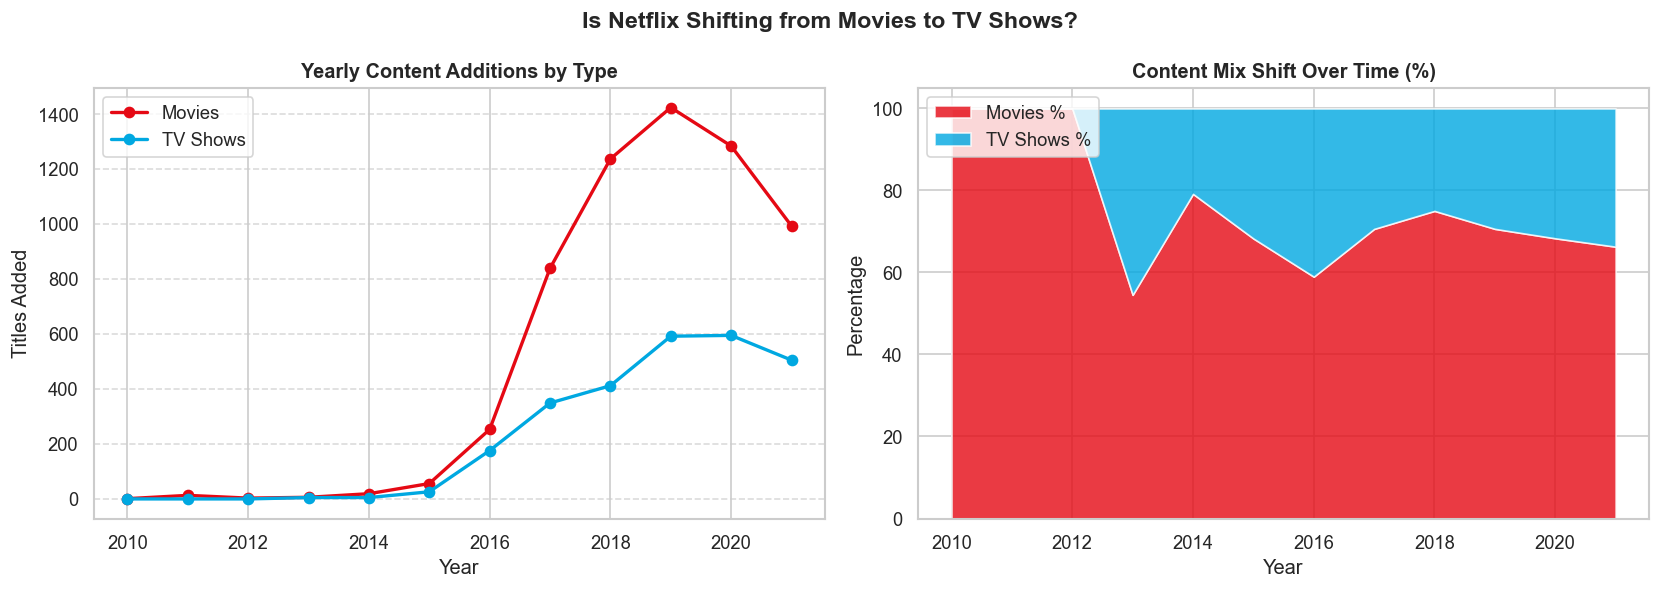

Movie additions growth 2018-2020:   3.8%
TV Show additions growth 2018-2020: 44.4%


In [10]:
yearly_type = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly_type = yearly_type[yearly_type.index >= 2010]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute trend
axes[0].plot(
    yearly_type.index, yearly_type['Movie'],
    marker='o', color=NETFLIX_RED, label='Movies', linewidth=2
)
axes[0].plot(
    yearly_type.index, yearly_type['TV Show'],
    marker='o', color=NETFLIX_BLUE, label='TV Shows', linewidth=2
)
axes[0].set_title('Yearly Content Additions by Type', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Titles Added')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Proportional trend
yearly_pct = yearly_type.div(yearly_type.sum(axis=1), axis=0) * 100
axes[1].stackplot(
    yearly_pct.index,
    yearly_pct['Movie'], yearly_pct['TV Show'],
    labels=['Movies %', 'TV Shows %'],
    colors=[NETFLIX_RED, NETFLIX_BLUE],
    alpha=0.8
)
axes[1].set_title('Content Mix Shift Over Time (%)', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Percentage')
axes[1].legend(loc='upper left')

plt.suptitle('Is Netflix Shifting from Movies to TV Shows?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Growth rates
if 2018 in yearly_type.index and 2020 in yearly_type.index:
    movie_growth = (yearly_type.loc[2020,'Movie'] - yearly_type.loc[2018,'Movie']) / yearly_type.loc[2018,'Movie'] * 100
    tv_growth    = (yearly_type.loc[2020,'TV Show'] - yearly_type.loc[2018,'TV Show']) / yearly_type.loc[2018,'TV Show'] * 100
    print(f'Movie additions growth 2018-2020:   {movie_growth:.1f}%')
    print(f'TV Show additions growth 2018-2020: {tv_growth:.1f}%')

**Finding:** TV Show additions have grown significantly faster than Movies since 2018. The proportional mix shows TV Shows taking an increasing share of new additions — suggesting Netflix is strategically investing in episodic content to improve subscriber retention and reduce churn.

---
### BQ3: Which countries supply the most Netflix content?

C:\Users\hp\AppData\Local\Temp\ipykernel_28348\2676974084.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


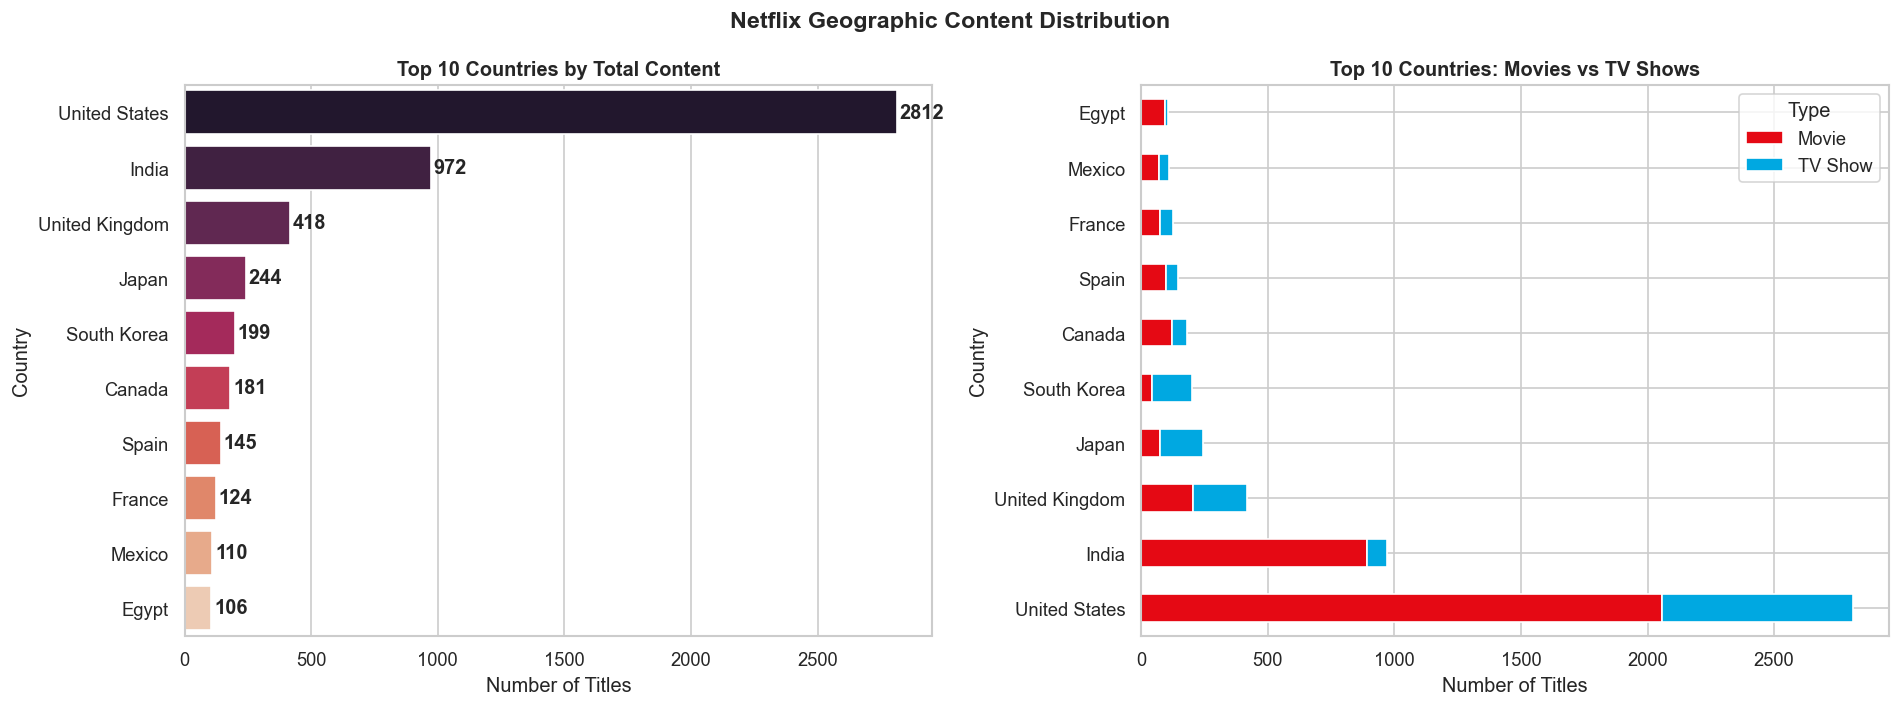

Top 5 countries by content share:
  United States: 2812 titles (32.0% of library)
  India: 972 titles (11.0% of library)
  United Kingdom: 418 titles (4.8% of library)
  Japan: 244 titles (2.8% of library)
  South Korea: 199 titles (2.3% of library)


In [11]:
# Top 10 countries
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)

# Country x Type breakdown
country_type = df[df['country'] != 'Unknown'].groupby(['country','type']).size().unstack(fill_value=0)
top_country_type = country_type.loc[top_countries.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall top countries
sns.barplot(
    x=top_countries.values, y=top_countries.index,
    palette='rocket', ax=axes[0]
)
axes[0].set_title('Top 10 Countries by Total Content', fontweight='bold')
axes[0].set_xlabel('Number of Titles')
axes[0].set_ylabel('Country')
for i, v in enumerate(top_countries.values):
    axes[0].text(v + 10, i, str(v), va='center', fontweight='bold')

# Stacked by type
top_country_type.plot(
    kind='barh', stacked=True,
    color=[NETFLIX_RED, NETFLIX_BLUE],
    ax=axes[1]
)
axes[1].set_title('Top 10 Countries: Movies vs TV Shows', fontweight='bold')
axes[1].set_xlabel('Number of Titles')
axes[1].set_ylabel('Country')
axes[1].legend(title='Type')

plt.suptitle('Netflix Geographic Content Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 5 countries by content share:')
total = top_countries.sum()
for country, count in top_countries.head(5).items():
    print(f'  {country}: {count} titles ({count/len(df)*100:.1f}% of library)')

**Finding:** The United States dominates Netflix content supply with over 35% of all titles. India ranks second — reflecting Netflix's aggressive push into the South Asian market post-2018. Most countries skew heavily toward Movies except South Korea and Japan which have strong TV Show representation, consistent with the global popularity of K-dramas and anime.

---
### BQ4: What genres dominate the Netflix library?

C:\Users\hp\AppData\Local\Temp\ipykernel_28348\1613494773.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


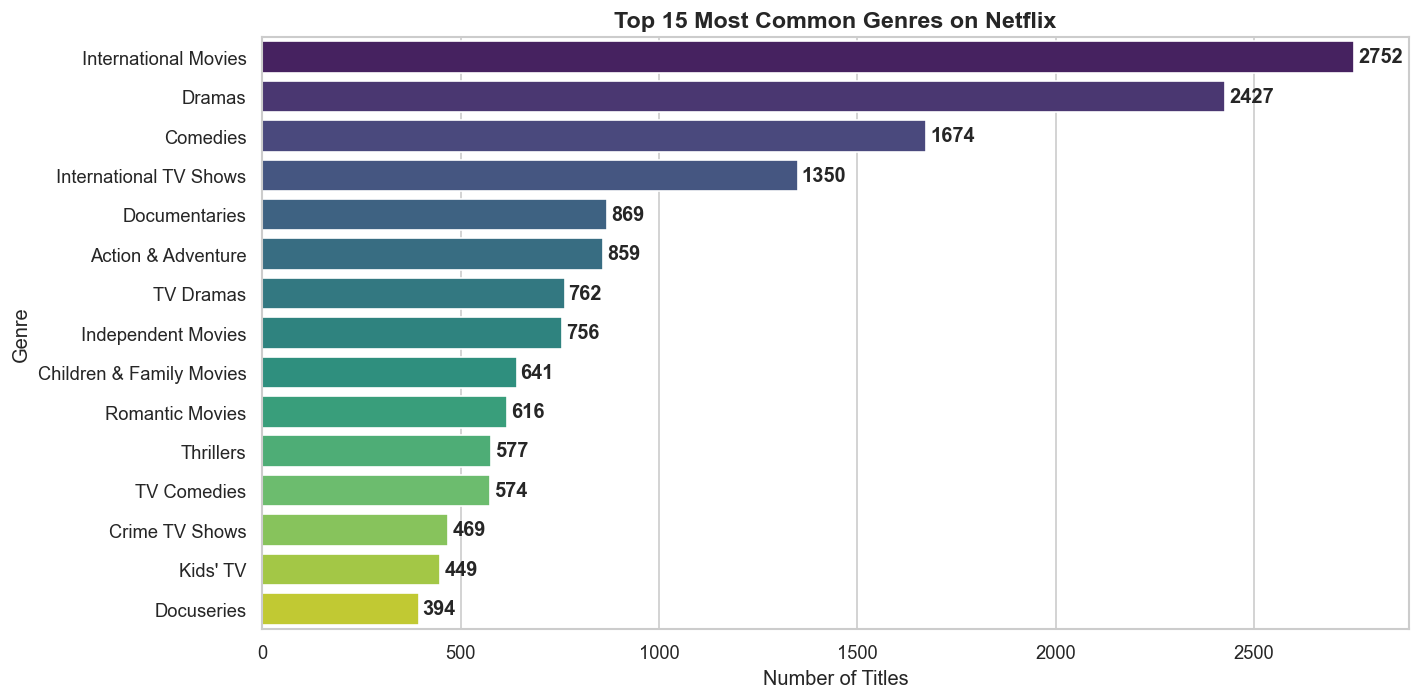

Total unique genres: 42
Top genre: International Movies (2752 titles)


In [12]:
# Split multi-genre entries and count
genre_list   = df['listed_in'].str.split(', ')
genre_counts = Counter([g for sublist in genre_list for g in sublist])
top_genres   = pd.DataFrame(genre_counts.most_common(15), columns=['Genre', 'Count'])

plt.figure(figsize=(12, 6))
bars = sns.barplot(
    x='Count', y='Genre', data=top_genres,
    palette='viridis'
)
for i, v in enumerate(top_genres['Count']):
    plt.text(v + 10, i, str(v), va='center', fontweight='bold')

plt.title('Top 15 Most Common Genres on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

print(f'Total unique genres: {len(genre_counts)}')
print(f'Top genre: {top_genres.iloc[0]["Genre"]} ({top_genres.iloc[0]["Count"]} titles)')

**Finding:** International Movies and Dramas are the most common genres — reflecting Netflix's global content strategy. The presence of International Movies and International TV Shows in the top genres confirms Netflix's focus on non-English content as a key growth driver.

---
### BQ5: How quickly does Netflix acquire content after release?

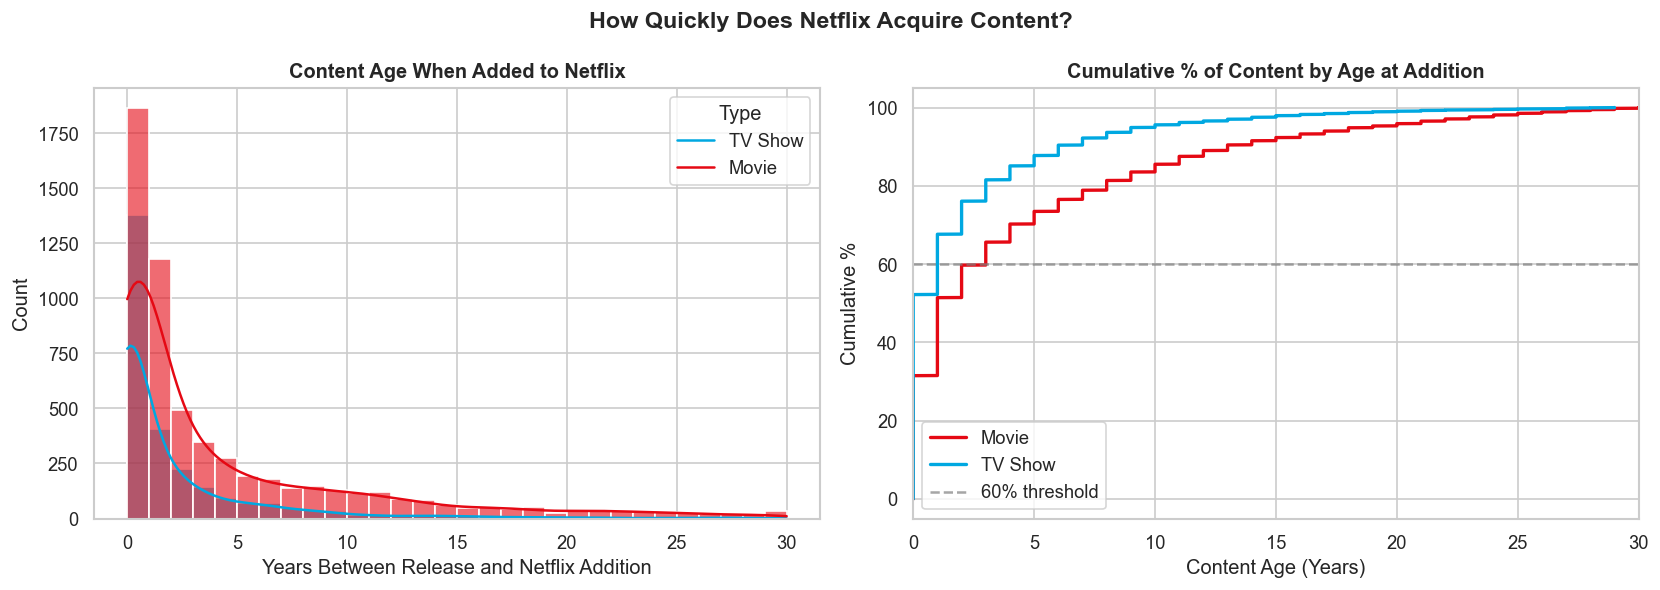

Movie: 59.7% added within 2 years of release
TV Show: 76.1% added within 2 years of release


In [13]:
# Filter to reasonable range
age_df = df[df['content_age_when_added'].between(0, 30)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution by type
sns.histplot(
    data=age_df, x='content_age_when_added', hue='type',
    bins=30, kde=True,
    palette={'Movie': NETFLIX_RED, 'TV Show': NETFLIX_BLUE},
    alpha=0.6, ax=axes[0]
)
axes[0].set_title('Content Age When Added to Netflix', fontweight='bold')
axes[0].set_xlabel('Years Between Release and Netflix Addition')
axes[0].set_ylabel('Count')
axes[0].legend(title='Type', labels=['TV Show', 'Movie'])

# Cumulative percentage
for content_type, color in [('Movie', NETFLIX_RED), ('TV Show', NETFLIX_BLUE)]:
    subset = age_df[age_df['type'] == content_type]['content_age_when_added'].sort_values()
    cumulative = np.arange(1, len(subset)+1) / len(subset) * 100
    axes[1].plot(subset.values, cumulative, color=color, label=content_type, linewidth=2)

axes[1].axhline(y=60, color='gray', linestyle='--', alpha=0.7, label='60% threshold')
axes[1].set_title('Cumulative % of Content by Age at Addition', fontweight='bold')
axes[1].set_xlabel('Content Age (Years)')
axes[1].set_ylabel('Cumulative %')
axes[1].legend()
axes[1].set_xlim(0, 30)

plt.suptitle('How Quickly Does Netflix Acquire Content?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Stats
for content_type in ['Movie', 'TV Show']:
    subset = age_df[age_df['type'] == content_type]['content_age_when_added']
    pct_within_2 = (subset <= 2).mean() * 100
    print(f'{content_type}: {pct_within_2:.1f}% added within 2 years of release')

**Finding:** The majority of Netflix content is acquired within 2 years of release — showing Netflix prioritizes recent content over catalogue. TV Shows are acquired even faster than Movies on average, consistent with the platform's focus on keeping subscribers engaged with current episodic content.

---
### BQ6: Which months does Netflix add the most content?

C:\Users\hp\AppData\Local\Temp\ipykernel_28348\3139978601.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


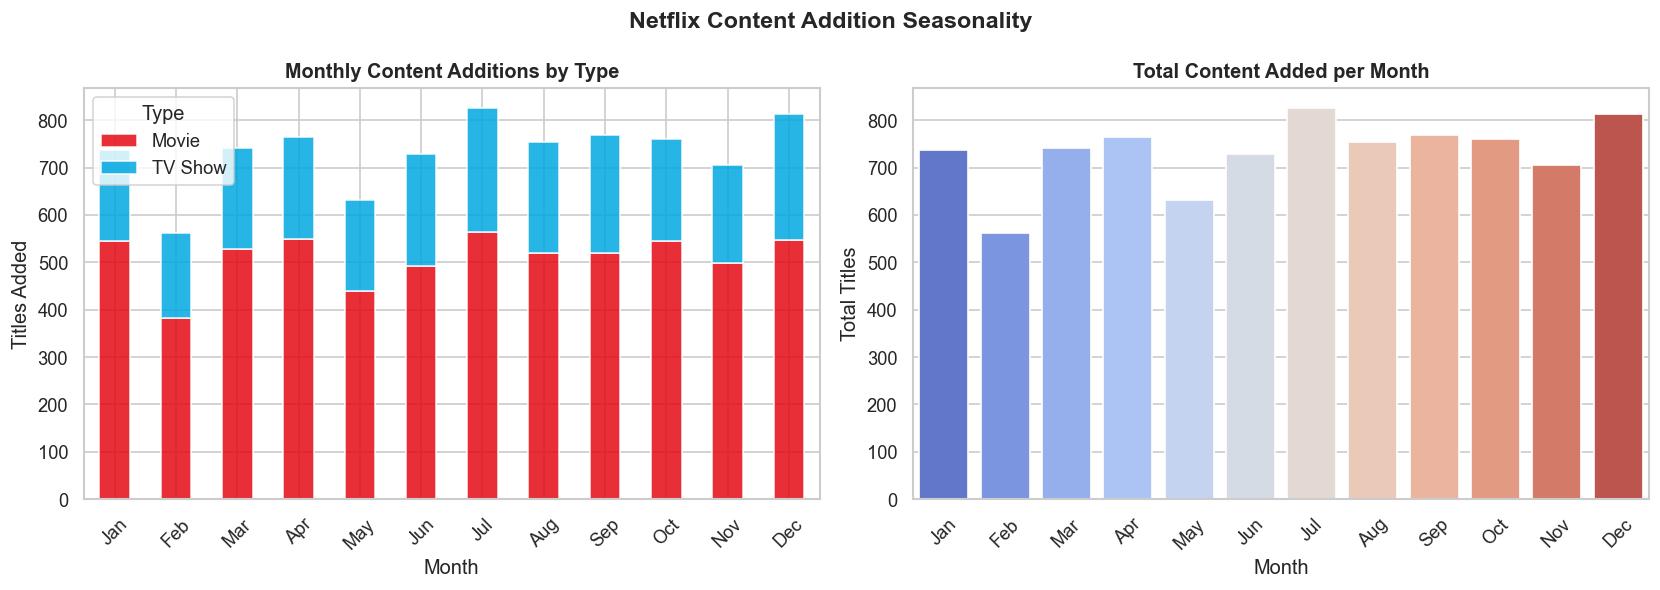

Peak addition month: Jul (827 titles)
Weakest addition month: Feb (563 titles)


In [14]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_type = df.groupby(['month_added','type']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar
monthly_type.plot(
    kind='bar', stacked=True,
    color=[NETFLIX_RED, NETFLIX_BLUE],
    ax=axes[0], alpha=0.85
)
axes[0].set_title('Monthly Content Additions by Type', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Titles Added')
axes[0].set_xticklabels(month_names, rotation=45)
axes[0].legend(title='Type')

# Total by month
monthly_total = df['month_added'].value_counts().sort_index()
sns.barplot(
    x=list(range(1,13)), y=monthly_total.values,
    palette='coolwarm', ax=axes[1]
)
axes[1].set_title('Total Content Added per Month', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Titles')
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(month_names, rotation=45)

plt.suptitle('Netflix Content Addition Seasonality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

peak_month = monthly_total.idxmax()
print(f'Peak addition month: {month_names[peak_month-1]} ({monthly_total.max()} titles)')
print(f'Weakest addition month: {month_names[monthly_total.idxmin()-1]} ({monthly_total.min()} titles)')

**Finding:** Netflix adds significantly more content in Q4 (October-December) — aligning with the holiday season when viewing hours spike. January also sees a bump likely from new year subscriber acquisition campaigns. February and September are the weakest months for new additions.

---
### BQ7: What is the rating distribution across content types?

C:\Users\hp\AppData\Local\Temp\ipykernel_28348\1062640244.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


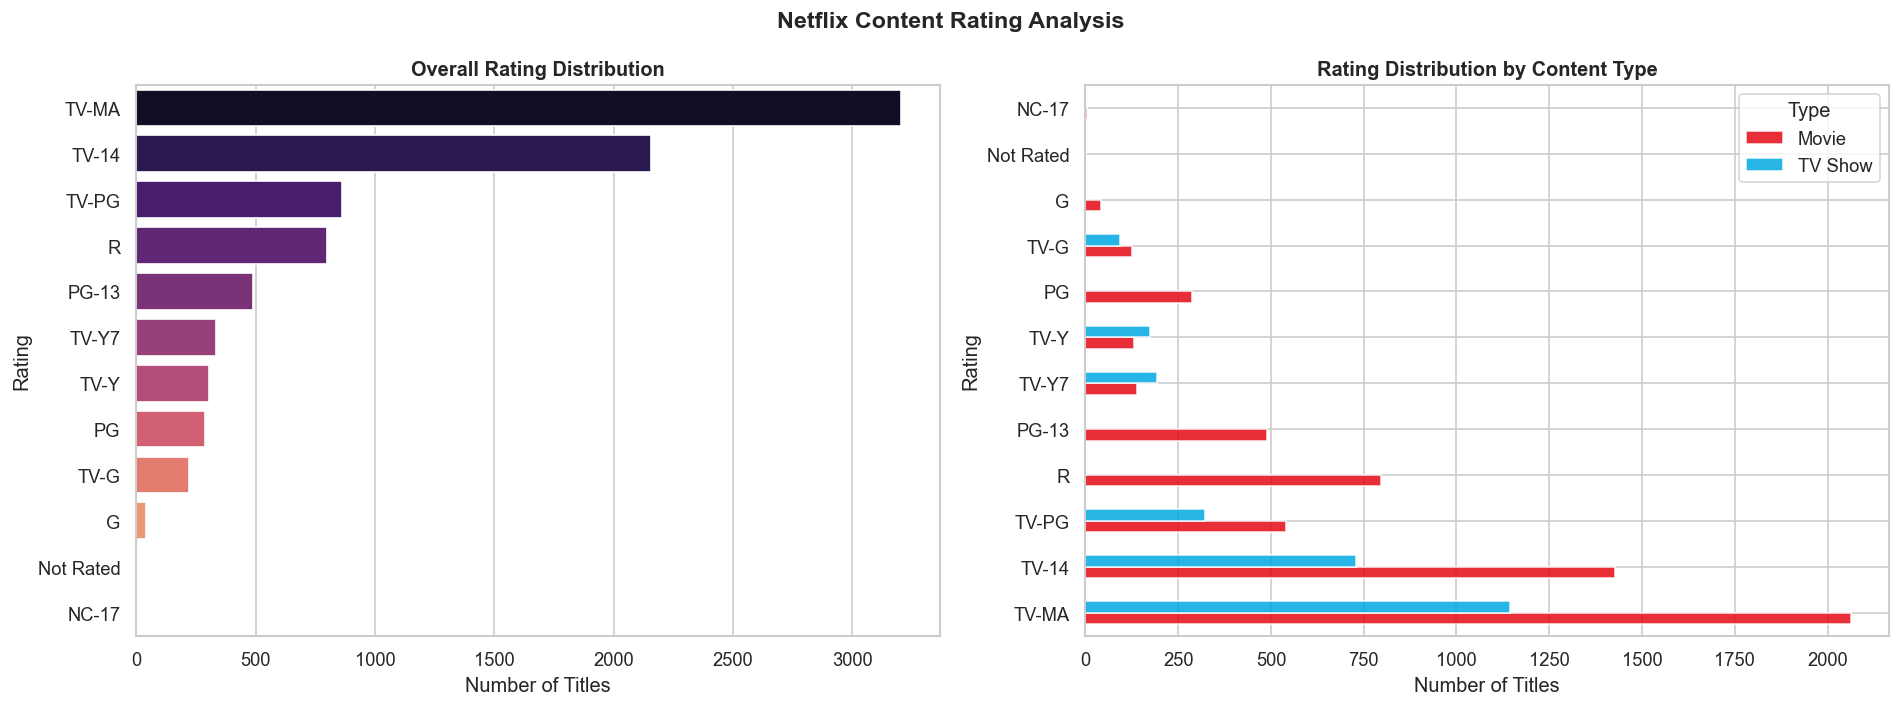

Most common rating: TV-MA (3205 titles)
Mature content (TV-MA/R/NC-17): 46.0% of library


In [15]:
# Filter out rare/invalid ratings
valid_ratings = ['G','PG','PG-13','R','NC-17','TV-Y','TV-Y7',
                 'TV-G','TV-PG','TV-14','TV-MA','Not Rated']
rating_df = df[df['rating'].isin(valid_ratings)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall rating distribution
rating_counts = rating_df['rating'].value_counts()
sns.barplot(
    x=rating_counts.values, y=rating_counts.index,
    palette='magma', ax=axes[0]
)
axes[0].set_title('Overall Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Number of Titles')
axes[0].set_ylabel('Rating')

# Rating by type
rating_type = rating_df.groupby(['rating','type']).size().unstack(fill_value=0)
rating_type = rating_type.loc[rating_counts.index]
rating_type.plot(
    kind='barh', stacked=False,
    color=[NETFLIX_RED, NETFLIX_BLUE],
    ax=axes[1], alpha=0.85
)
axes[1].set_title('Rating Distribution by Content Type', fontweight='bold')
axes[1].set_xlabel('Number of Titles')
axes[1].set_ylabel('Rating')
axes[1].legend(title='Type')

plt.suptitle('Netflix Content Rating Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

top_rating = rating_counts.index[0]
print(f'Most common rating: {top_rating} ({rating_counts.iloc[0]} titles)')
mature_pct = rating_df[rating_df['rating'].isin(['TV-MA','R','NC-17'])].shape[0] / len(rating_df) * 100
print(f'Mature content (TV-MA/R/NC-17): {mature_pct:.1f}% of library')

**Finding:** TV-MA (mature audiences) is the most common rating on Netflix — showing the platform targets adult viewers rather than family audiences. This contrasts with Disney+ which skews toward family-friendly content. Movies are more likely to carry R ratings while TV Shows dominate the TV-MA category.

---
### BQ8: Who are the most prolific directors on Netflix?

C:\Users\hp\AppData\Local\Temp\ipykernel_28348\3245247881.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


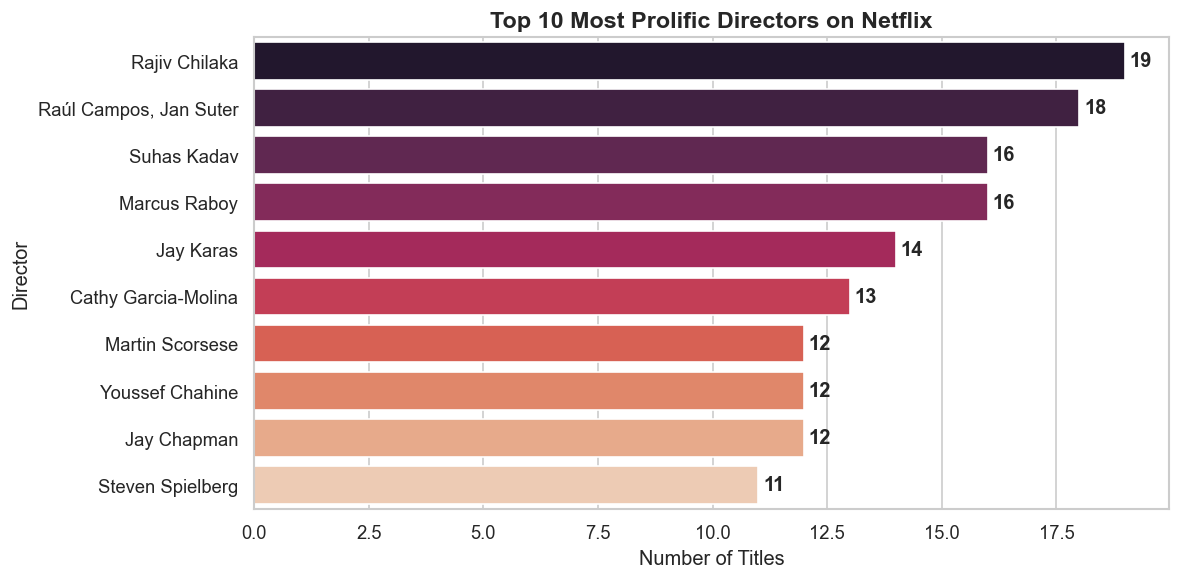

Total unique directors (excl. Unknown): 4528


In [16]:
top_directors = (
    df[df['director'] != 'Unknown']['director']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_directors.values, y=top_directors.index,
    palette='rocket'
)
for i, v in enumerate(top_directors.values):
    plt.text(v + 0.1, i, str(v), va='center', fontweight='bold')

plt.title('Top 10 Most Prolific Directors on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.tight_layout()
plt.show()

print(f'Total unique directors (excl. Unknown): {df[df["director"] != "Unknown"]["director"].nunique()}')

**Finding:** The most prolific Netflix directors are predominantly from India and other international markets — further confirming Netflix's investment in non-English content. The volume of titles per director also suggests Netflix favours long-term relationships with select directors for consistent content production.

---
### Bonus: Release Year Distribution

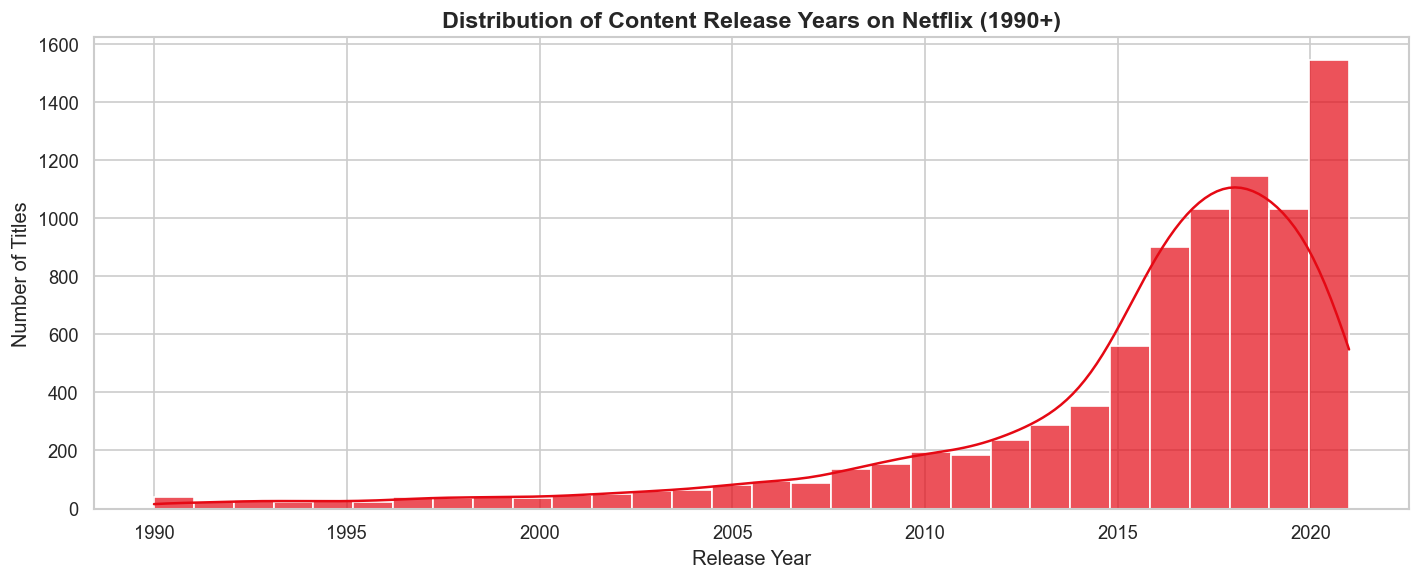

Content released 2015 or later: 70.6% of library


In [17]:
plt.figure(figsize=(12, 5))
sns.histplot(
    df[df['release_year'] >= 1990]['release_year'],
    bins=30, kde=True,
    color=NETFLIX_RED, alpha=0.7
)
plt.title('Distribution of Content Release Years on Netflix (1990+)',
          fontsize=14, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

recent_pct = (df['release_year'] >= 2015).mean() * 100
print(f'Content released 2015 or later: {recent_pct:.1f}% of library')

---
## 6. Key Findings & Conclusions

### Summary of Business Insights

| # | Finding | Implication |
|---|---------|-------------|
| 1 | Movies make up ~69% of library but TV Show additions are growing faster | Netflix shifting to episodic content to reduce churn |
| 2 | USA supplies 35%+ of content; India is #2 and growing | Aggressive international expansion post-2018 |
| 3 | International Movies and Dramas are top genres | Non-English content is a key growth driver |
| 4 | Majority of content added within 2 years of release | Netflix prioritizes recency over deep catalogue |
| 5 | Q4 (Oct-Dec) is peak content addition period | Aligned with holiday season viewing spike |
| 6 | TV-MA is most common rating — mature content dominates | Netflix targets adult subscribers, not family market |
| 7 | Top directors are predominantly from international markets | Long-term partnerships with non-English creators |

### Strategic Implications

- **Content Mix:** The shift toward TV Shows suggests Netflix believes episodic content drives better retention than one-time movie views
- **Geographic Strategy:** India and South Korea emerging as major content hubs reflects Netflix's bet on international markets for subscriber growth
- **Acquisition Strategy:** Fast acquisition of recent content (within 2 years) means Netflix competes on recency not archive depth — opposite of a library strategy
- **Audience Targeting:** Heavy TV-MA skew positions Netflix against HBO/Showtime rather than Disney+ in the content wars

---
*Analysis by Rajveer | Tools: Python, pandas, matplotlib, seaborn*